# Data Engineering & EDA Workshop

This notebook demonstrates a complete data engineering workflow using Python, 
Pandas, Faker, and a cloud PostgreSQL database hosted on Neon.

The workflow includes:

- Data generation and collection
- PostgreSQL database connection
- Data cleaning
- Data transformation
- Feature engineering
- Salary scaling
- Exploratory data analysis (EDA)
- Data visualization
- Joining employee data with department data
- Advanced visualization
- Insights and conclusions

## 1. Data Collection & Database Connection

In this section, synthetic employee data will be generated using the Faker 
library. The data will contain IT-related positions, employee start dates, 
and salaries. The generated records will then be stored in a PostgreSQL 
database hosted on Neon.

In [10]:
# Import the libraries needed for this project

import pandas as pd
import psycopg2
from faker import Faker
import random

In [11]:
# Create a Faker object
fake = Faker()
    
# Make random results reproducible
random.seed(42)
Faker.seed(42)

### Data Collection

The employee dataset is synthetic data generated with the Python Faker library.
At least 50 employee records will be created. The data will represent fictional
IT employees and will include employee IDs, names, job positions, start dates,
and salaries.

The data is synthetic and does not represent real employees.

In [12]:
# List of IT-related positions

positions = [
    "Software Developer",
    "Data Analyst",
    "Data Engineer",
    "Web Developer",
    "Database Administrator",
    "Cybersecurity Analyst",
    "Cloud Engineer",
    "Machine Learning Engineer",
    "Systems Analyst",
    "IT Support Specialist"
]

positions

['Software Developer',
 'Data Analyst',
 'Data Engineer',
 'Web Developer',
 'Database Administrator',
 'Cybersecurity Analyst',
 'Cloud Engineer',
 'Machine Learning Engineer',
 'Systems Analyst',
 'IT Support Specialist']

In [13]:
# Generate 50 synthetic employee records

employees = []

for employee_id in range(1, 51):
    
    employee = {
        "employee_id": employee_id,
        "name": fake.name(),
        "position": random.choice(positions),
        "start_date": fake.date_between(
            start_date="-11y",
            end_date="-2y"
        ),
        "salary": random.randint(60000, 200000)
    }
    
    employees.append(employee)

# Convert the list into a Pandas DataFrame
employees_df = pd.DataFrame(employees)

# Display the first 5 records
employees_df.head()

,employee_id,name,position,start_date,salary
0,1,Allison Hill,Data Analyst,2019-07-10,66556
1,2,Brian Yang,Database Administrator,2017-03-16,124196
2,3,Amanda Davis,Web Developer,2019-09-07,96579
3,4,Alyssa Gonzalez,Data Analyst,2022-11-11,82790
4,5,Kevin Pacheco,IT Support Specialist,2015-11-02,170604


In [14]:
# Check the number of rows and columns

employees_df.shape

(50, 5)

In [15]:
# Check the minimum and maximum salary

print("Minimum salary:", employees_df["salary"].min())
print("Maximum salary:", employees_df["salary"].max())

# Check the earliest and latest start dates

print("Earliest start date:", employees_df["start_date"].min())
print("Latest start date:", employees_df["start_date"].max())

Minimum salary: 66556
Maximum salary: 192475
Earliest start date: 2015-09-26
Latest start date: 2023-12-29


## 1.1 Create and Connect to the Neon PostgreSQL Database

A free PostgreSQL database was created using Neon. The database will be used
to store the synthetic employee data and demonstrate how Python can connect
to a cloud SQL database.


In [16]:
import os
from dotenv import load_dotenv

# 1. Load the environment variables from the .env file
load_dotenv()

# 2. Fetch the DATABASE_URL environment variable
connection_string = os.getenv("DATABASE_URL")


# Connect to the Neon database
conn = psycopg2.connect(connection_string)

# Create a cursor to execute SQL commands
cursor = conn.cursor()

print("Connected to Neon PostgreSQL successfully!")

Connected to Neon PostgreSQL successfully!


### Creating the Employees Table

The `employees` table will contain five required columns:

- `employee_id` – unique employee identifier
- `name` – employee name
- `position` – IT-related job title
- `start_date` – employee start date
- `salary` – annual salary

In [17]:
# SQL command to create the employees table

create_table_query = """
CREATE TABLE IF NOT EXISTS employees (
    employee_id INTEGER PRIMARY KEY,
    name VARCHAR(100),
    position VARCHAR(100),
    start_date DATE,
    salary INTEGER
);
"""

# Execute the SQL command
cursor.execute(create_table_query)

# Save the change
conn.commit()

print("Employees table created successfully!")

Employees table created successfully!


### Inserting Employee Data

The synthetic employee records generated with Faker will now be inserted
into the PostgreSQL `employees` table.

In [18]:
# SQL command for inserting employee data

insert_query = """
INSERT INTO employees (employee_id, name, position, start_date, salary)
VALUES (%s, %s, %s, %s, %s)
ON CONFLICT (employee_id) DO NOTHING;
"""

# Insert each employee into the database
for _, row in employees_df.iterrows():
    cursor.execute(
        insert_query,
        (
            row["employee_id"],
            row["name"],
            row["position"],
            row["start_date"],
            row["salary"]
        )
    )

# Save all inserted records
conn.commit()

print("Employee data inserted successfully!")

Employee data inserted successfully!


In [19]:
# Count the number of records in the employees table

cursor.execute("SELECT COUNT(*) FROM employees;")

employee_count = cursor.fetchone()[0]

print("Number of employees in database:", employee_count)

Number of employees in database: 50


### Loading Data from PostgreSQL into Pandas

The employee table will now be queried from Neon PostgreSQL and loaded into
a Pandas DataFrame. This allows Python and Pandas to be used for cleaning,
transformation, analysis, and visualization.

In [20]:
# SQL query to retrieve all employees

query = "SELECT * FROM employees;"

# Load the SQL query result directly into a Pandas DataFrame
df = pd.read_sql_query(query, conn)

# Display the first 5 rows
df.head()

C:\Users\Ubaid\AppData\Local\Temp\ipykernel_13600\2330931133.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,employee_id,name,position,start_date,salary
0,1,Allison Hill,Data Analyst,2019-07-10,66556
1,2,Brian Yang,Database Administrator,2017-03-16,124196
2,3,Amanda Davis,Web Developer,2019-09-07,96579
3,4,Alyssa Gonzalez,Data Analyst,2022-11-11,82790
4,5,Kevin Pacheco,IT Support Specialist,2015-11-02,170604


In [21]:
# Display the shape of the loaded DataFrame

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50
Columns: 5


## 2. Data Cleaning

Data cleaning is the process of checking the dataset for missing, duplicate,
or invalid values before performing analysis.

The following checks will be performed:

- Data types
- Missing values
- Duplicate employee IDs
- Salary values
- Start dates

In [22]:
# Display information about the DataFrame

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   employee_id  50 non-null     int64 
 1   name         50 non-null     str   
 2   position     50 non-null     str   
 3   start_date   50 non-null     object
 4   salary       50 non-null     int64 
dtypes: int64(2), object(1), str(2)
memory usage: 2.1+ KB


In [23]:
# Check for missing values in each column

df.isnull().sum()

employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64

In [24]:
# Check for duplicate employee IDs

print("Duplicate employee IDs:", df["employee_id"].duplicated().sum())

Duplicate employee IDs: 0


In [25]:
# Check whether any salaries are below $60,000 or above $200,000

invalid_salary = df[
    (df["salary"] < 60000) |
    (df["salary"] > 200000)
]

print("Invalid salary records:", len(invalid_salary))

Invalid salary records: 0


In [26]:
# Convert start_date to Pandas datetime format

df["start_date"] = pd.to_datetime(
    df["start_date"],
    errors="coerce"
)

# Check the data type
df["start_date"].dtype

dtype('<M8[s]')

## 3. Data Transformation & Feature Engineering

Data transformation changes the existing data into a format that is easier
to analyze.

A `start_year` column will be created by extracting the year from the
employee's start date.

A `years_of_service` column will also be created to estimate how many years
each employee has worked based on their start date.

In [27]:
# Extract the year from start_date

df["start_year"] = df["start_date"].dt.year

# Display the first 5 rows
df.head()

,employee_id,name,position,start_date,salary,start_year
0,1,Allison Hill,Data Analyst,2019-07-10,66556,2019
1,2,Brian Yang,Database Administrator,2017-03-16,124196,2017
2,3,Amanda Davis,Web Developer,2019-09-07,96579,2019
3,4,Alyssa Gonzalez,Data Analyst,2022-11-11,82790,2022
4,5,Kevin Pacheco,IT Support Specialist,2015-11-02,170604,2015


In [28]:
# we'll calculate service as of December 31, 2024

# Define a fixed reference date

reference_date = pd.Timestamp("2024-12-31")

# Calculate years of service
df["years_of_service"] = (
    (reference_date - df["start_date"]).dt.days / 365.25
).round(1)

# Display the result
df[["name", "start_date", "years_of_service"]].head() 

,name,start_date,years_of_service
0,Allison Hill,2019-07-10,5.5
1,Brian Yang,2017-03-16,7.8
2,Amanda Davis,2019-09-07,5.3
3,Alyssa Gonzalez,2022-11-11,2.1
4,Kevin Pacheco,2015-11-02,9.2


## 4. Scaling

Salary values range from $60,000 to $200,000. Scaling converts the salary
values into a common numerical range.

Min-Max scaling will be used to transform salary values to a range between
0 and 1.

This creates a standardized version of salary that can be useful for
machine learning and numerical analysis.

In [29]:
# Import MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

In [30]:
# Create the scaler
scaler = MinMaxScaler()

# Scale the salary column
df["salary_scaled"] = scaler.fit_transform(
    df[["salary"]]
)

# Display original and scaled salary
df[["salary", "salary_scaled"]].head()

,salary,salary_scaled
0,66556,0.000000
1,124196,0.457755
2,96579,0.238431
3,82790,0.128924
4,170604,0.826309


### Descriptive Statistics

Descriptive statistics provide a summary of the numerical columns in the
employee dataset. The statistics include count, mean, standard deviation,
minimum, maximum, and quartiles.

In [31]:
# Display descriptive statistics

df.describe()

,employee_id,start_date,salary,start_year,years_of_service,salary_scaled
count,50.00000,50,50.000000,50.000000,50.000000,50.000000
mean,25.50000,2019-06-18 11:02:24,125541.080000,2018.940000,5.538000,0.468437
min,1.00000,2015-09-26 00:00:00,66556.000000,2015.000000,1.000000,0.000000
25%,13.25000,2017-05-30 00:00:00,97623.750000,2017.000000,4.050000,0.246728
50%,25.50000,2019-07-01 00:00:00,126763.500000,2019.000000,5.500000,0.478145
75%,37.75000,2020-12-02 18:00:00,152390.250000,2020.750000,7.600000,0.681662
max,50.00000,2023-12-29 00:00:00,192475.000000,2023.000000,9.300000,1.000000
std,14.57738,NaN,37025.365107,2.298269,2.300656,0.294041


## 5. Visualization 1: Average Salary by Position and Start Year

The first visualization compares the average employee salary across IT
positions and employee start years.

Grouping the data by position and start year allows us to see how average
salary differs between job roles and hiring years.

In [32]:
# Calculate average salary by position and start year

avg_salary = (
    df.groupby(["position", "start_year"])["salary"]
      .mean()
      .reset_index()
)

# Display the grouped data
avg_salary.head(10)

,position,start_year,salary
0,Cloud Engineer,2017,180285.0
1,Cloud Engineer,2018,114925.0
2,Cloud Engineer,2021,85353.0
3,Cloud Engineer,2022,130765.0
4,Cybersecurity Analyst,2016,153132.0
5,Cybersecurity Analyst,2019,119912.5
6,Cybersecurity Analyst,2021,102638.0
7,Cybersecurity Analyst,2023,150165.0
8,Data Analyst,2016,84312.0
9,Data Analyst,2017,114400.0


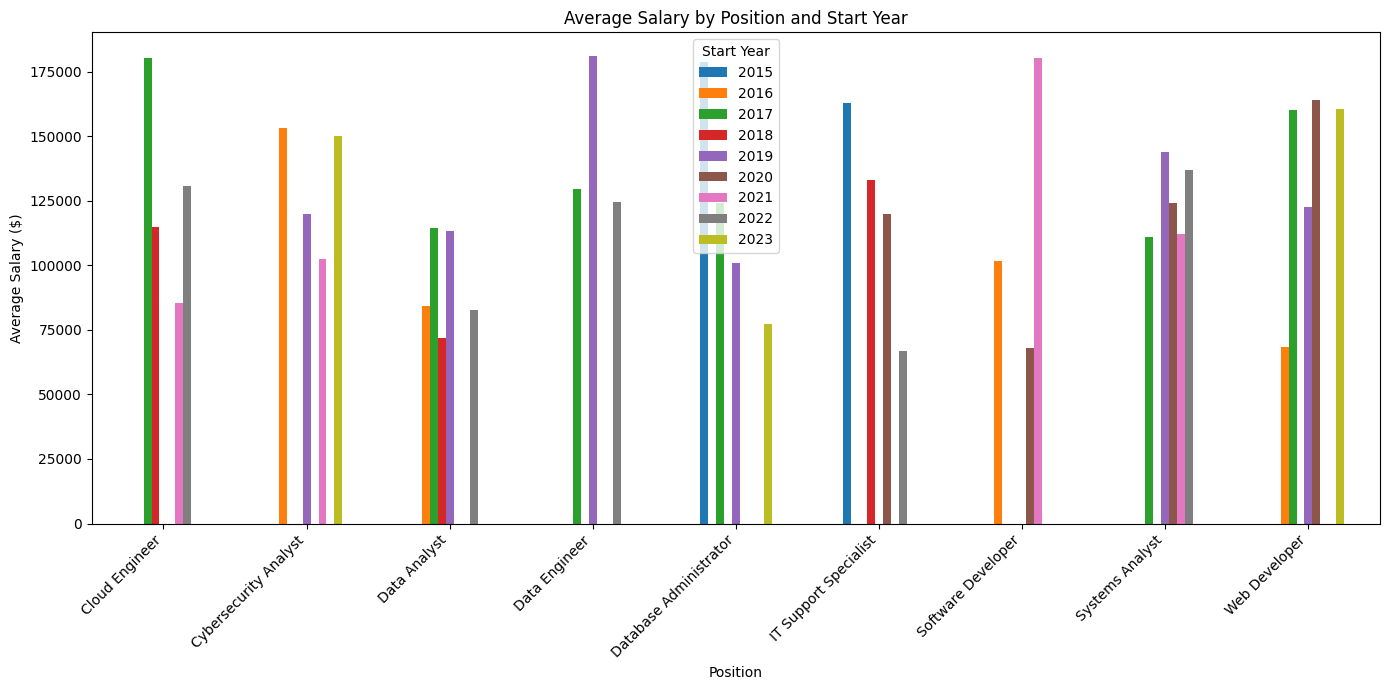

In [33]:
import matplotlib.pyplot as plt

# Reshape the data for the grouped bar chart
chart_data = avg_salary.pivot(
    index="position",
    columns="start_year",
    values="salary"
)

# Create the chart
chart_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Average Salary by Position and Start Year")
plt.xlabel("Position")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Start Year")
plt.tight_layout()

plt.show()

### Insights from Visualization 1

The chart shows that average salary varies across positions and start years. Some of the highest averages appear for Cloud Engineer, Data Engineer, and Software Developer roles in particular years. However, there is no consistent salary trend over time because the synthetic dataset contains different numbers of employees for each position and year.

## 6. Advanced Dataset: Departments

To make the dataset more complex, a second dataset containing department
information will be created.

Each department will have:

- department_id
- department_name
- location
- budget

The employee data will then be joined with the department data using
`department_id`.

There is one important change we need to make first: our current employee table doesn't have department_id.

So I'll add it.

In [34]:
# Create department IDs for the employees

department_ids = [1, 2, 3, 4, 5]

random.seed(42)

df["department_id"] = [
    random.choice(department_ids)
    for _ in range(len(df))
]

# Display the result
df.head()

,employee_id,name,position,start_date,salary,start_year,years_of_service,salary_scaled,department_id
0,1,Allison Hill,Data Analyst,2019-07-10,66556,2019,5.5,0.000000,1
1,2,Brian Yang,Database Administrator,2017-03-16,124196,2017,7.8,0.457755,1
2,3,Amanda Davis,Web Developer,2019-09-07,96579,2019,5.3,0.238431,3
3,4,Alyssa Gonzalez,Data Analyst,2022-11-11,82790,2022,2.1,0.128924,2
4,5,Kevin Pacheco,IT Support Specialist,2015-11-02,170604,2015,9.2,0.826309,2


In [35]:
# Create a second dataset containing department information

departments_df = pd.DataFrame({
    "department_id": [1, 2, 3, 4, 5],
    "department_name": [
        "Software Development",
        "Data & Analytics",
        "Cybersecurity",
        "Cloud & Infrastructure",
        "IT Support"
    ],
    "location": [
        "Toronto",
        "Waterloo",
        "Ottawa",
        "Mississauga",
        "Hamilton"
    ],
    "budget": [
        2500000,
        2200000,
        1800000,
        2100000,
        1500000
    ]
})

departments_df

,department_id,department_name,location,budget
0,1,Software Development,Toronto,2500000
1,2,Data & Analytics,Waterloo,2200000
2,3,Cybersecurity,Ottawa,1800000
3,4,Cloud & Infrastructure,Mississauga,2100000
4,5,IT Support,Hamilton,1500000


### Joining the Datasets

The employee DataFrame and department DataFrame will be joined using
`department_id`.

This creates a more complex dataset that combines employee information with
department details.

In [36]:
# Merge employee data with department data

employee_department_df = pd.merge(
    df,
    departments_df,
    on="department_id",
    how="left"
)

# Display the first 5 rows
employee_department_df.head()

,employee_id,name,position,start_date,salary,start_year,years_of_service,salary_scaled,department_id,department_name,location,budget
0,1,Allison Hill,Data Analyst,2019-07-10,66556,2019,5.5,0.000000,1,Software Development,Toronto,2500000
1,2,Brian Yang,Database Administrator,2017-03-16,124196,2017,7.8,0.457755,1,Software Development,Toronto,2500000
2,3,Amanda Davis,Web Developer,2019-09-07,96579,2019,5.3,0.238431,3,Cybersecurity,Ottawa,1800000
3,4,Alyssa Gonzalez,Data Analyst,2022-11-11,82790,2022,2.1,0.128924,2,Data & Analytics,Waterloo,2200000
4,5,Kevin Pacheco,IT Support Specialist,2015-11-02,170604,2015,9.2,0.826309,2,Data & Analytics,Waterloo,2200000


###  Visualization 2: Average Salary by Department and Position

The second visualization uses the more complex dataset created by joining
employee information with department information.

A heatmap will be used to compare average salaries across departments and
IT positions.

The heatmap makes it easier to identify areas where average salaries are
higher or lower across the two categories.

In [37]:
# Calculate average salary by department and position

heatmap_data = employee_department_df.pivot_table(
    values="salary",
    index="department_name",
    columns="position",
    aggfunc="mean"
)

# Display the table
heatmap_data

position,Cloud Engineer,Cybersecurity Analyst,Data Analyst,Data Engineer,Database Administrator,IT Support Specialist,Software Developer,Systems Analyst,Web Developer
department_name,,,,,,,,,
Cloud & Infrastructure,NaN,NaN,121024.0,155307.0,NaN,NaN,NaN,133183.333333,142490.00
Cybersecurity,NaN,119912.5,159647.0,NaN,178858.0,110407.0,NaN,117570.000000,113282.50
Data & Analytics,114925.000000,127885.0,82790.0,NaN,100758.0,149973.0,67811.0,NaN,135861.00
IT Support,NaN,150165.0,84312.0,NaN,NaN,154800.0,180435.0,120500.000000,149998.75
Software Development,132134.333333,NaN,90186.0,124651.0,100773.0,99941.0,101853.0,124175.000000,177757.00


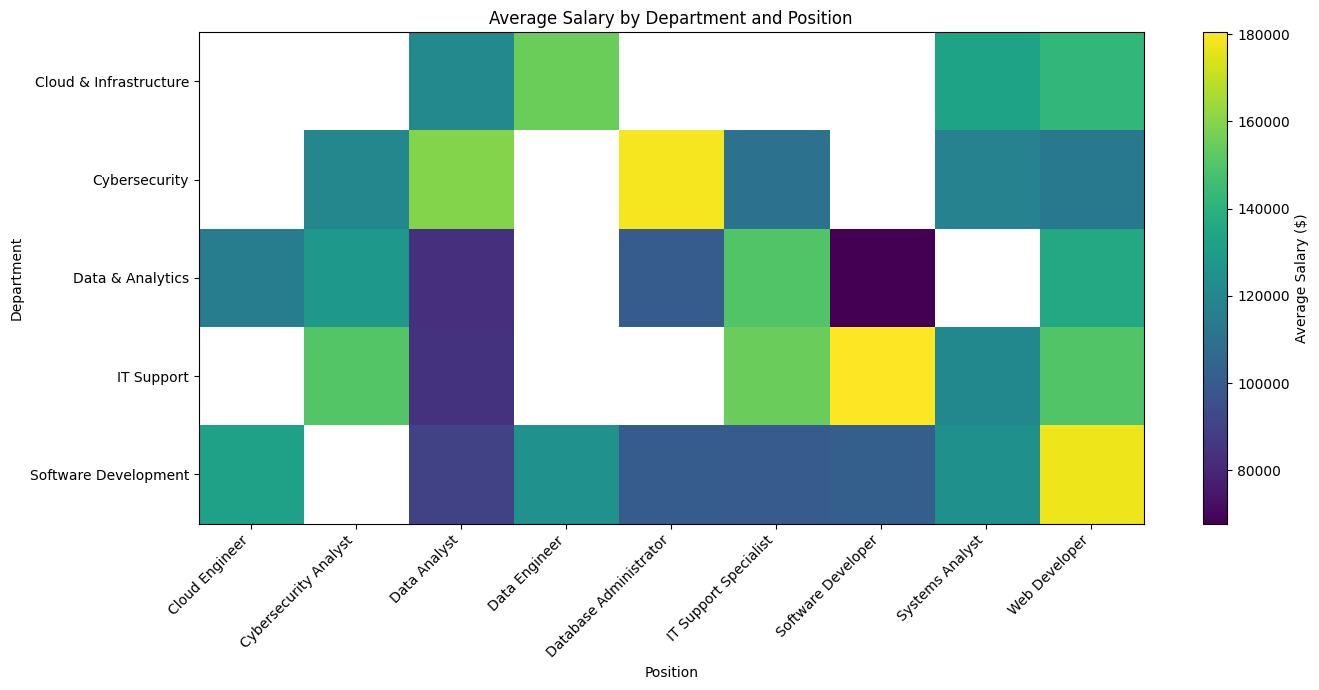

In [38]:
import matplotlib.pyplot as plt

# Create the heatmap
plt.figure(figsize=(14, 7))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

# Add labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(label="Average Salary ($)")

plt.title("Average Salary by Department and Position")
plt.xlabel("Position")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

### Insights from Visualization 2

The heatmap shows that average salary differs across departments and positions. The highest values are visible for Database Administrator in Cybersecurity, Software Developer in IT Support, and Web Developer in Software Development. Blank areas indicate combinations for which no employee records were available in the dataset.

## 8. Insights & Conclusions

This project demonstrated a complete data engineering and exploratory data
analysis workflow.

The employee data was generated using Faker and stored in a cloud PostgreSQL
database hosted on Neon. Python and Pandas were then used to retrieve,
inspect, clean, transform, and analyze the data.

Feature engineering was performed by creating `start_year` and
`years_of_service`. Salary values were also scaled using Min-Max scaling.

The first visualization compared average salary by position and start year.
The second visualization used a joined employee and department dataset to
compare average salary across departments and positions.

Overall, this project demonstrated how data can move from data generation
and cloud storage through data cleaning, transformation, analysis, and
visualization.